# Revenue-Only Prediction Model (Anonymized Data)

This notebook builds a reproducible **revenue-only** prediction pipeline from anonymized program data.

It will:
- Load anonymized investment, baseline, and endline datasets with robust path and encoding handling
- Build a merged modeling table keyed by client linkage fields
- Predict endline revenue as `revenue_3m` using a chronological split
- Evaluate and export only revenue model artifacts

All risk and employment prediction paths are intentionally excluded.

In [ ]:
print("Revenue prediction model notebook loaded successfully.")

Revenue prediction model notebook loaded successfully.


In [ ]:
import io
import warnings
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

def find_ml_dir(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents]
    for c in candidates:
        if (c / "ml" / "Anomynized data").exists():
            return c / "ml"
        if (c / "Anomynized data").exists():
            return c
    raise FileNotFoundError(
        f"Could not locate ML data directory from {start}. Expected an 'ml/Anomynized data' or 'Anomynized data' folder in current/parent paths."
    )

def load_csv_with_fallback(path: Path) -> pd.DataFrame:
    for enc in ["utf-8", "latin-1", "cp1252"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raw = path.read_bytes()
    text = raw.decode("utf-8", errors="replace")
    return pd.read_csv(io.StringIO(text))

BASE_DIR = Path.cwd().resolve()
ML_DIR = find_ml_dir(BASE_DIR)
ANON_DIR = ML_DIR / "Anomynized data" / "Anomynized data" / "Anomynized data"

ARTIFACTS_DIR = ML_DIR / "artifacts"
MODELS_DIR = ARTIFACTS_DIR / "models"
METRICS_DIR = ARTIFACTS_DIR / "metrics"
PREDICTIONS_DIR = ARTIFACTS_DIR / "predictions"
CHARTS_DIR = ML_DIR / "charts"

for d in [ARTIFACTS_DIR, MODELS_DIR, METRICS_DIR, PREDICTIONS_DIR, CHARTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

INVESTMENT_PATH = ANON_DIR / "Investment data_all clients_RW-KE-ET-SS_2021-2025_Inkomoko.csv"
BASELINE_PATH = ANON_DIR / "baseline_RW-ET-SS_existing businesses 2022-2025_Inkomoko.csv"
ENDLINE_PATH = ANON_DIR / "endline_RW-ET-SS_existing businesses 2022-2025_Inkomoko.csv"
TARGET_REVENUE = "revenue_3m"

print(f"BASE_DIR: {BASE_DIR}")
print(f"ML_DIR: {ML_DIR}")
print(f"Anonymized data dir exists: {ANON_DIR.exists()} -> {ANON_DIR}")
print(f"Investment exists: {INVESTMENT_PATH.exists()} -> {INVESTMENT_PATH}")
print(f"Baseline exists: {BASELINE_PATH.exists()} -> {BASELINE_PATH}")
print(f"Endline exists: {ENDLINE_PATH.exists()} -> {ENDLINE_PATH}")

In [ ]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    cols = []
    seen = {}
    for c in df.columns:
        name = str(c).strip()
        if name in seen:
            seen[name] += 1
            name = f"{name}_{seen[name]}"
        else:
            seen[name] = 0
        cols.append(name)
    out = df.copy()
    out.columns = cols
    return out

def parse_dates(df: pd.DataFrame, date_cols: List[str], dayfirst: bool = False) -> pd.DataFrame:
    out = df.copy()
    for c in date_cols:
        if c in out.columns:
            out[c] = pd.to_datetime(out[c], errors="coerce", dayfirst=dayfirst)
    return out

def to_num(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = (
                out[c]
                .astype(str)
                .str.replace(",", "", regex=False)
                .str.replace("#REF!", "", regex=False)
                .str.replace("$", "", regex=False)
            )
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

investment_df = load_csv_with_fallback(INVESTMENT_PATH)
baseline_df = load_csv_with_fallback(BASELINE_PATH)
endline_df = load_csv_with_fallback(ENDLINE_PATH)

investment = normalize_columns(investment_df)
baseline = normalize_columns(baseline_df)
endline = normalize_columns(endline_df)

investment = parse_dates(investment, ["submissionDate", "approvalDate", "disbursementDate", "lastPaymentDate"], dayfirst=False)
baseline = parse_dates(baseline, ["survey_date"], dayfirst=True)
endline = parse_dates(endline, ["survey_date"], dayfirst=True)

inv_num_cols = [
    "daysInArrears", "installmentInArrears",
    "approvedAmount", "disbursedAmount", "actualPaymentAmount",
    "amountPastDue", "scheduledPaymentAmount", "principalPaid",
    "currentBalance", "interestBalance", "feesBalance",
    "termsDuration", "cycle",
    "age",
    "lastPaymentAmount",
    "scheduledPrincipalAmount", "scheduledInterestAmount", "scheduledFeesAmount",
    "principalPastDue", "interestPastDue", "feesPastDue",
    "DisbursementYear",
]
baseline_num_cols = ["revenue", "hh_expense", "monthly_customer", "job_created", "number_of_people_reponsible", "age"]
endline_num_cols = baseline_num_cols + ["nps_detractor", "nps_passive", "nps_promoter", "satisfied_yes", "satisfied_no"]

investment = to_num(investment, inv_num_cols)
baseline = to_num(baseline, baseline_num_cols)
endline = to_num(endline, endline_num_cols)

for df, col in [(investment, "BaselineEndlineClientId"), (investment, "ClientId"), (baseline, "client_id"), (endline, "client_id")]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

loan_sort_col = "disbursementDate" if "disbursementDate" in investment.columns else "approvalDate"
investment = investment.sort_values(["ClientId", loan_sort_col])
loan_latest = investment.groupby("ClientId", as_index=False).tail(1).copy()

loan_latest["repayment_ratio"] = loan_latest["actualPaymentAmount"] / loan_latest["scheduledPaymentAmount"].replace(0, np.nan)
loan_latest["utilization_ratio"] = loan_latest["disbursedAmount"] / loan_latest["approvedAmount"].replace(0, np.nan)
loan_latest["past_due_ratio"] = loan_latest["amountPastDue"] / loan_latest["scheduledPaymentAmount"].replace(0, np.nan)
loan_latest["principal_completion_ratio"] = loan_latest["principalPaid"] / loan_latest["disbursedAmount"].replace(0, np.nan)

baseline_ctx = baseline[[c for c in ["client_id", "survey_date", "revenue", "hh_expense", "monthly_customer", "business_sector", "business_location", "education_level", "gender", "strata", "have_bank_account", "is_business_registered"] if c in baseline.columns]].copy()
baseline_ctx = baseline_ctx.rename(columns={"survey_date": "baseline_survey_date", "revenue": "baseline_revenue", "hh_expense": "baseline_hh_expense", "monthly_customer": "baseline_monthly_customer"})

endline_ctx = endline[[c for c in ["client_id", "survey_date", "revenue", "hh_expense", "monthly_customer", "business_sector", "business_location", "education_level", "gender", "strata", "have_bank_account", "is_business_registered", "nps_detractor", "nps_passive", "nps_promoter", "satisfied_yes", "satisfied_no"] if c in endline.columns]].copy()
endline_ctx = endline_ctx.rename(columns={"survey_date": "endline_survey_date", "revenue": "endline_revenue", "hh_expense": "endline_hh_expense", "monthly_customer": "endline_monthly_customer"})

survey_ctx = baseline_ctx.merge(endline_ctx, on="client_id", how="outer", suffixes=("_baseline", "_endline"))

model_df = loan_latest.merge(
    survey_ctx,
    left_on="BaselineEndlineClientId",
    right_on="client_id",
    how="left",
)

model_df["survey_date"] = model_df["endline_survey_date"]
model_df[TARGET_REVENUE] = pd.to_numeric(model_df.get("endline_revenue"), errors="coerce")
model_df["revenue_to_expense_ratio"] = model_df[TARGET_REVENUE] / pd.to_numeric(model_df.get("endline_hh_expense"), errors="coerce").replace(0, np.nan)

join_coverage = model_df["client_id"].notna().mean() if "client_id" in model_df.columns else 0.0
target_coverage = model_df[TARGET_REVENUE].notna().mean()
print(f"Join coverage (loan->survey): {join_coverage:.2%}")
print(f"Target coverage (endline revenue): {target_coverage:.2%}")

for c in model_df.columns:
    if hasattr(model_df[c], "dtype") and model_df[c].dtype.kind in "fiu":
        model_df[c] = model_df[c].replace([np.inf, -np.inf], np.nan)

model_df = model_df.dropna(subset=["survey_date", TARGET_REVENUE]).sort_values("survey_date").reset_index(drop=True)

if len(model_df) < 10:
    raise ValueError("Not enough rows after filtering to train a stable revenue model (need at least 10 rows).")

split_idx = min(max(1, int(len(model_df) * 0.8)), len(model_df) - 1)
train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

drop_cols = {
    "survey_date", "client_id", "ClientId", "BaselineEndlineClientId", "loanNumber",
    TARGET_REVENUE, "endline_revenue", "baseline_revenue",
    "baseline_survey_date", "endline_survey_date",
}
feature_cols = [c for c in model_df.columns if c not in drop_cols]

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()
y_train = train_df[TARGET_REVENUE].copy()
y_test = test_df[TARGET_REVENUE].copy()

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

if len(num_cols) + len(cat_cols) == 0:
    raise ValueError("No usable feature columns found after preprocessing and leakage filtering.")

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))]), cat_cols),
    ],
    remainder="drop",
)

print(f"Rows total/train/test: {len(model_df)} / {len(train_df)} / {len(test_df)}")
print(f"Features: {len(feature_cols)} (num={len(num_cols)}, cat={len(cat_cols)})")
display(model_df[["survey_date", TARGET_REVENUE, "ClientId", "BaselineEndlineClientId"]].head(5))

Train rows: 8000, Test rows: 2000, Features: 90


In [ ]:
revenue_model = Pipeline([
    ("prep", preprocess),
    ("reg", RandomForestRegressor(n_estimators=350, random_state=SEED, n_jobs=-1)),
])

revenue_model.fit(X_train, y_train)
revenue_pred = np.clip(revenue_model.predict(X_test), 0, None)

revenue_rmse = float(np.sqrt(mean_squared_error(y_test, revenue_pred)))
revenue_mae = float(mean_absolute_error(y_test, revenue_pred))

revenue_metrics_df = pd.DataFrame([
    {"target": TARGET_REVENUE, "rmse": round(revenue_rmse, 6), "mae": round(revenue_mae, 6), "rows_train": len(train_df), "rows_test": len(test_df)}
])

print("Revenue model trained")
display(revenue_metrics_df)

,target,rmse,mae
0,revenue_3m,68.776781,42.87925


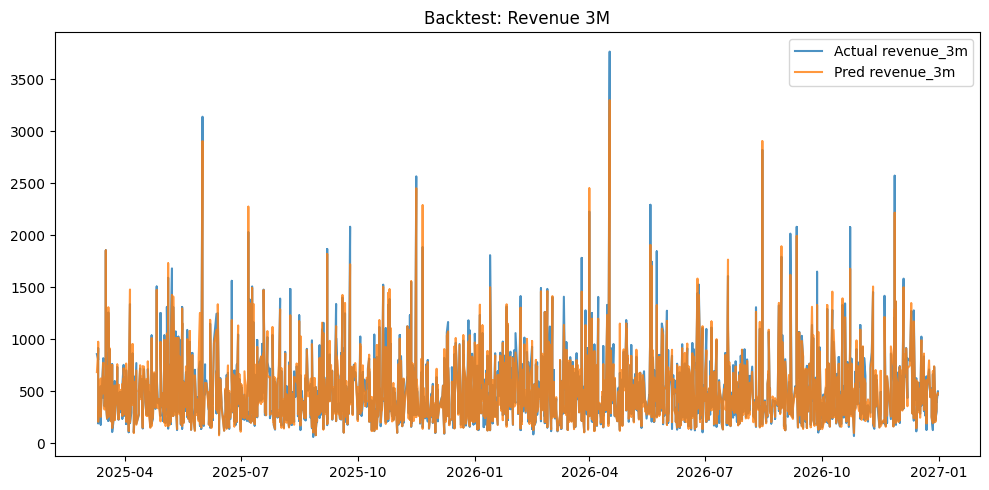

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(test_df["survey_date"], y_test.values, label="Actual revenue_3m", alpha=0.8)
ax.plot(test_df["survey_date"], revenue_pred, label="Pred revenue_3m", alpha=0.8)
ax.set_title("Backtest: Revenue 3M")
ax.set_xlabel("survey_date")
ax.set_ylabel("revenue")
ax.legend()
plt.tight_layout()
plt.savefig(CHARTS_DIR / "revenue_backtest.png", dpi=150)
plt.show()

In [ ]:
base_export = model_df.iloc[X_test.index][["ClientId", "BaselineEndlineClientId", "survey_date", TARGET_REVENUE]].reset_index(drop=True).copy()
base_export["pred_revenue_3m"] = revenue_pred
revenue_export = base_export

joblib.dump(revenue_model, MODELS_DIR / "revenue_3m_model.joblib")
revenue_metrics_df.to_csv(METRICS_DIR / "revenue_model_metrics.csv", index=False)
revenue_export.to_csv(PREDICTIONS_DIR / "revenue_predictions_test.csv", index=False)

print("Saved:")
print(" -", METRICS_DIR / "revenue_model_metrics.csv")
print(" -", PREDICTIONS_DIR / "revenue_predictions_test.csv")
print(" -", MODELS_DIR / "revenue_3m_model.joblib")
print(" -", CHARTS_DIR / "revenue_backtest.png")

display(revenue_export.head())

Saved:
 - ml/artifacts/revenue_model_metrics.csv
 - ml/artifacts/revenue_predictions_test.csv
 - ml/artifacts/revenue_3m_model.joblib


,unique_id,survey_date,revenue_3m,pred_revenue_3m
0,U01097,2025-03-10,855.27,682.298133
1,U01353,2025-03-11,801.83,882.235133
2,U04241,2025-03-11,695.62,743.123700
3,U00118,2025-03-11,911.05,973.551533
4,U04702,2025-03-11,371.51,346.138300
